In [7]:
'''Exercise 4: NumPy Array Operations'''
import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# Hint: Use np.ones and array slicing
matrix_border=np.ones((5,5))
#[1:-1] selects the second row/column to the last but one row/column
matrix_border[1: -1, 1: -1] = 0
print(matrix_border)


# Task 2: Normalize a random array
# TODO: Normalize each column to have mean=0 and std=1
np.random.seed(42)
random_data = np.random.randn(100,3)
normalized_matrix = (random_data - random_data.mean(axis=0))/random_data.std(axis=0)



# Task 3: Implement linear regression solution using normal equation
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print(theta_hat)
print(true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[ 2.51723721 -1.19783796  3.72399266]
[ 2.5 -1.2  3.7]


In [18]:
'''Exercise 5: Panda Data Analysis'''

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration
# TODO: Display basic information about the dataset
# TODO: Identify and count missing values
# TODO: Fill missing exam_score with the mean score for the student's major
# TODO: Fill missing hours_studied with the median for the student's year
print("DataFrame Information")
print(df.info())
print(df.describe())
print("Missing Values")
print(df.isnull().sum())



# Task 2: Analysis
# TODO: Calculate and display the average exam_score by major
# TODO: Find the major with the highest average exam_score
# TODO: Calculate the correlation between hours_studied and exam_score
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
exam_avg_by_major = df.groupby('major')['exam_score'].mean()
print(exam_avg_by_major)
max_avg_major = exam_avg_by_major.idxmax()
print(max_avg_major)
correlation = df['hours_studied'].corr(df['exam_score'])
print(correlation)
def performance_category(score):
    if score >= 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'
df['performance'] = df['exam_score'].apply(performance_category)

# Task 3: Advanced Analysis
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
major_year = df.groupby(['major', 'year']).agg(num_of_studs=('student_id', 'count'),
                                                avg_exam_score=('exam_score', 'mean'),
                                                avg_hours_studied=('hours_studied', 'mean'))
print(major_year)
top_5_studs = df.sort_values('exam_score', ascending=False).head(5)
print(top_5_studs)
pivot_table = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean')
print(pivot_table)


DataFrame Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910    

<Axes: xlabel='performance', ylabel='exam_score'>

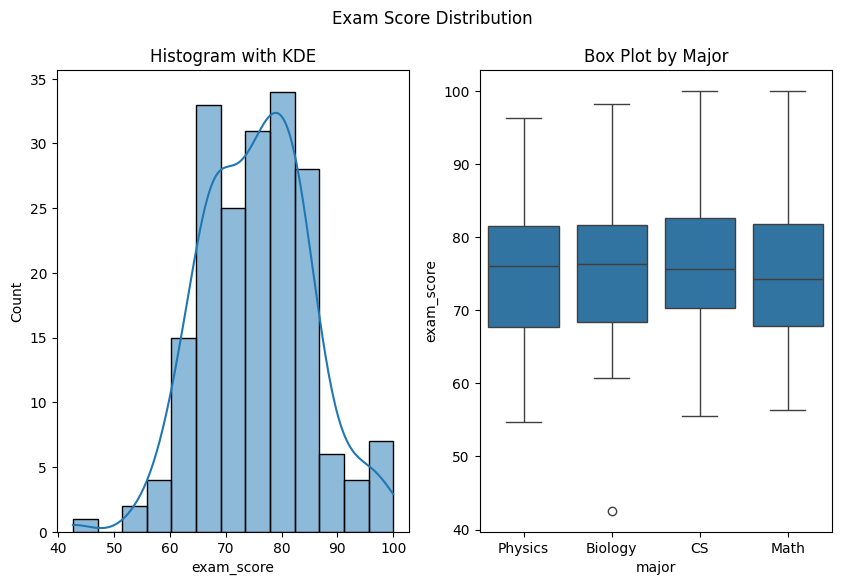

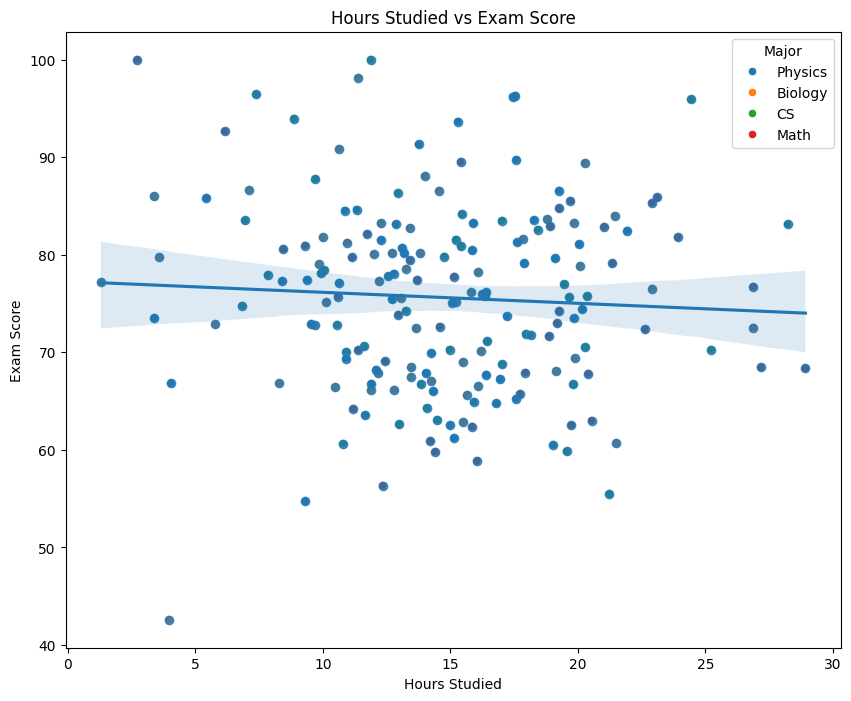

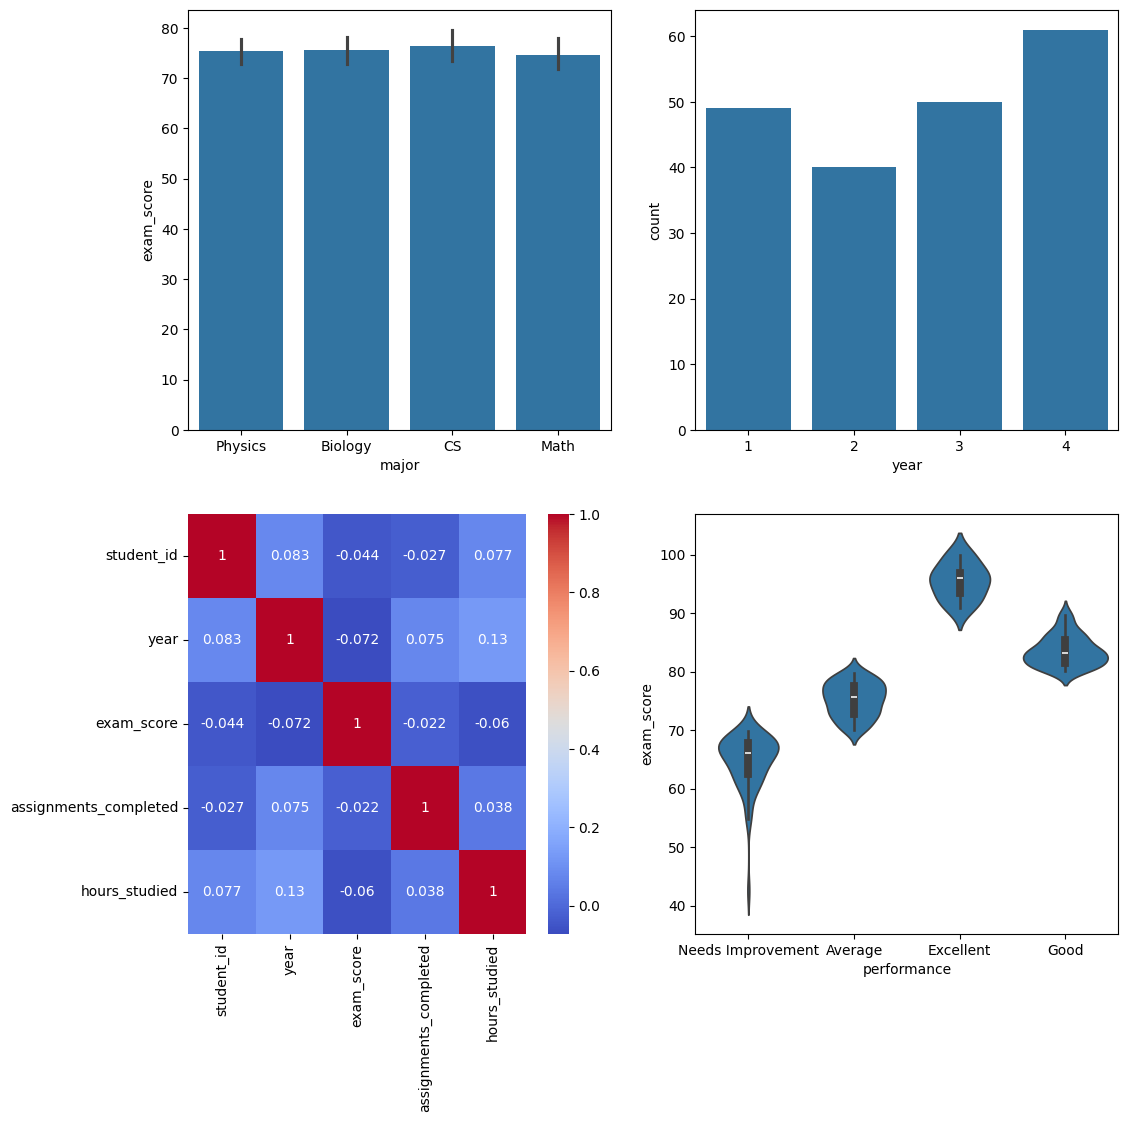

In [22]:
'''Exercise 6: Data Visualisation'''

import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10, 6))
sns.histplot(data=df, x='exam_score', kde=True, ax=ax1)
sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
fig.suptitle('Exam Score Distribution', fontsize = 12)
ax1.set_title('Histogram with KDE')
ax2.set_title('Box Plot by Major')


# Task 2: Relationship Visualization
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
fig1, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major', ax=ax)
sns.regplot(data=df, x='hours_studied', y='exam_score')
ax.legend(title='Major')
ax.set_title('Hours Studied vs Exam Score')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')


# Task 3: Advanced Dashboard
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability
fig2, ax= plt.subplots(2, 2, figsize=(12, 12))
ax_bar_chart=ax[0, 0]
ax_count_plot=ax[0, 1]
ax_heatmap=ax[1, 0]
ax_violin_plot=ax[1, 1]
sns.barplot(data=df, x='major', y='exam_score', ax=ax_bar_chart)
sns.countplot(data=df, x='year', ax=ax_count_plot)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=ax_heatmap)
sns.violinplot(data=df, x='performance', y='exam_score', ax=ax_violin_plot)

           num_of_customers    avg_income     avg_clv     total_clv
age_group                                                          
18-25                   112  48347.736075  714.533342  80027.734266
26-35                   126  50437.687271  773.936041  97515.941150
36-50                   135  48848.685273  736.789653  99466.603171
51-70                   127  51106.940472  747.016928  94871.149806
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   
423   43  34443.666248                   6          173.245130    0.500000   
386   63  24200.782005                   9    

<Axes: >

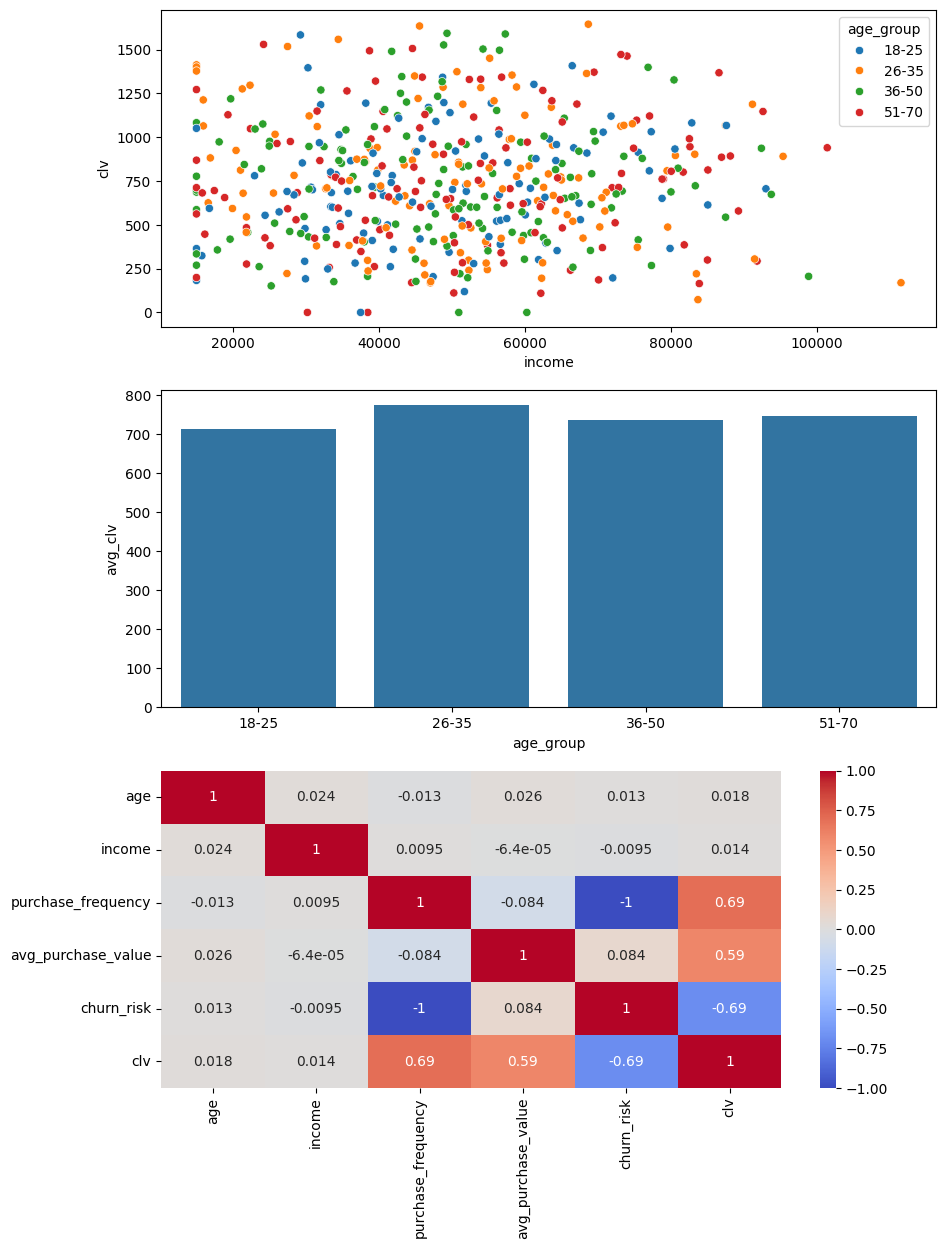

In [32]:
'''Exercise 7: Integration Challenge'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500


ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['clv'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

#TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
age_groups = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=4, labels=age_groups)

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
age_group = customers.groupby('age_group', observed=False).agg(num_of_customers=('age', 'count'),
                                               avg_income=('income', 'mean'),
                                               avg_clv=('clv', 'mean'),
                                               total_clv=('clv', 'sum'))
print(age_group)

# TODO: Identify top 10% of customers by CLV
top_10_percent_of_customers = customers.sort_values('clv', ascending=False).head(int(0.1 * len(customers)))
print(top_10_percent_of_customers)

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
fig3, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))
sns.scatterplot(data=customers, x='income', y='clv', hue='age_group', ax=ax1)

sns.barplot(data=age_group, x=age_group.index, y='avg_clv', ax=ax2)

sns.heatmap(customers.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=ax3)


# TODO: Write a brief analysis paragraph (as a markdown cell) summarising key findings and recommendations
**Key Findings**
-
**Recommendations**
-Target more youth customers(18-25) because they have the longest poential lifetime.
-The top 10% of customers by CLV should be given loyalty rewards like warrants and maybe VIP programs.  